# PREDIÇÃO NO DATASET
Carrega um modelo de `Backup/`, avalia o IoU no dataset em que ele foi treinado e desenha
algumas predições.

O dataset é lido do próprio `info.json` do modelo, e os volumes são cortados na **janela em
que ele foi treinado** (`img_size`: 128³, 64³, 32³, 32×64×16 …). Rodar o volume inteiro numa
rede treinada em blocos menores muda as estatísticas do GroupNorm e o contexto que ela viu
no treino — o IoU cai sem motivo aparente.

In [9]:
import os, cv2, json, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import sys, gc
sys.path.append("..")
from Network.index import ModelNetwork
from utils.index import showTile

In [10]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


In [11]:
models = [f'model_{i}' for i in sorted([int(path.split('_')[-1]) for path in os.listdir('Backup')])]
models 

['model_1',
 'model_2',
 'model_3',
 'model_4',
 'model_5',
 'model_6',
 'model_7',
 'model_8',
 'model_9',
 'model_10',
 'model_11',
 'model_12',
 'model_13',
 'model_14',
 'model_15',
 'model_16',
 'model_17',
 'model_18',
 'model_19',
 'model_20']

In [12]:
modelId = models[-1]   # ou 'model_1' para fixar um modelo

baseDir = f'Backup/{modelId}'

if not os.path.exists(baseDir):
    print(f"Error: Model {modelId} not found at {baseDir}")

modelInfo = json.loads(open(f'{baseDir}/info.json', 'r').read())

dataset    = modelInfo.get('processing', {}).get('dataset', 'dataset_wu')
datasetDir = f'../Dataset/{dataset}'

if not os.path.exists(datasetDir):
    print(f"Error: Dataset {dataset} not found at {datasetDir}")

IMG_SIZE = modelInfo.get('model', {}).get('img_size') or 128
IMG_SIZE = tuple([IMG_SIZE] * 3 if np.isscalar(IMG_SIZE) else IMG_SIZE)

print(f'{modelId}: {dataset}, janela {IMG_SIZE}')

model_20: dataset_wu, janela (128, 128, 128)


In [13]:
modelOptions = modelInfo.get('model', {})
print("Model Options:")
print(json.dumps(modelOptions, indent=4))

network   = ModelNetwork(**modelOptions)
modelData = torch.load(f'{baseDir}/model.pth', map_location=network.device)

network.model.load_state_dict(modelData['model'])
network.model.eval()
print(f"Weights from {modelId} loaded successfully!")

Model Options:
{
    "network": "macnn",
    "img_size": [
        128,
        128,
        128
    ],
    "classes": 1,
    "channels": 1,
    "dropout": 0.0,
    "num_filters": 32,
    "lr": 0.0001
}
Weights from model_20 loaded successfully!


In [14]:
DATABASE = f'{datasetDir}/DataBase.csv'

if not os.path.exists(DATABASE):
    raise FileNotFoundError(f'{DATABASE} nao existe. Rode o Format.ipynb de {dataset} uma vez para gera-lo.')

dfPredict = pd.read_csv(DATABASE)[['img_path', 'mask_path']]
shape     = np.load(dfPredict.img_path.iloc[0], mmap_mode='r').shape

print(f'{DATABASE}: {len(dfPredict)} volumes de shape {shape}')
dfPredict.head()

../Dataset/dataset_wu/DataBase.csv: 220 volumes de shape (128, 128, 128)


,img_path,mask_path
0,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
1,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
2,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
3,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
4,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...


In [15]:
class PredictDataset(Dataset):
    def __init__(self, df, window):
        self.df     = df.reset_index(drop=True)
        self.shape  = np.load(self.df.img_path.iloc[0], mmap_mode='r').shape
        self.window = tuple(min(int(w), int(s)) for w, s in zip(window, self.shape))
        self.starts = [self.getStarts(s, w) for s, w in zip(self.shape, self.window)]
        self.blocks = [(row, d, h, w) for row in range(len(self.df)) for d in self.starts[0] for h in self.starts[1] for w in self.starts[2]]

    # INICIO DE CADA BLOCO NUM EIXO; O ULTIMO ENCOSTA NO FIM DO VOLUME
    @staticmethod
    def getStarts(size, window):
        return sorted(set(list(range(0, size - window + 1, window)) + [size - window]))

    def __len__(self):
        return len(self.blocks)

    def __getitem__(self, index):
        fileIndex, d, h, w = self.blocks[index]
        row = self.df.iloc[fileIndex]
        wd, wh, ww = self.window

        img  = np.asarray(np.load(row.img_path,  mmap_mode='r')[d:d + wd, h:h + wh, w:w + ww], np.float32)
        mask = np.asarray(np.load(row.mask_path, mmap_mode='r')[d:d + wd, h:h + wh, w:w + ww], np.float32)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


predictDataset = PredictDataset(dfPredict, IMG_SIZE)
BATCH_SIZE = int(np.clip(128 ** 3 // int(np.prod(predictDataset.window)), 1, 256))

predictLoader = DataLoader(
    predictDataset, 
    batch_size=BATCH_SIZE,
    shuffle=False, 
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f'{len(dfPredict)} volumes {predictDataset.shape} -> {len(predictDataset)} blocos de {predictDataset.window} (lote {BATCH_SIZE})')

220 volumes (128, 128, 128) -> 220 blocos de (128, 128, 128) (lote 1)


In [16]:
def getMetrics(network, loader):
    network.model.eval()
    network.iou.reset()
    tp = tn = fp = fn = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Avaliando'):
            imgs, masks = imgs.to(network.device), masks.to(network.device)
            logits = network.model(imgs)

            if network.multiclass:
                preds  = torch.argmax(logits, dim=1)
                target = masks.squeeze(1) if masks.dim() == 5 else masks
            else:
                preds  = (torch.sigmoid(logits) > 0.5)
                target = masks

            network.iou.update(preds, target.int())

            falha = target.bool()
            achou = preds.bool()
            tp += int((achou & falha).sum())
            tn += int((~achou & ~falha).sum())
            fp += int((achou & ~falha).sum())
            fn += int((~achou & falha).sum())

    total = tp + tn + fp + fn
    return {
        'accuracy':  (tp + tn) / total if total else 0.0,
        'precision': tp / (tp + fp) if (tp + fp) else 0.0,
        'recall':    tp / (tp + fn) if (tp + fn) else 0.0,
        'iou':       tp / (tp + fp + fn) if (tp + fp + fn) else 0.0,
        'iou_torchmetrics': network.iou.compute().item(),
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    }

In [17]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.045454545454545456
VAL_SIZE  = TEST_SIZE / (1 - TEST_SIZE)

restDf, testDf = train_test_split(dfPredict, test_size=TEST_SIZE, random_state=42)
trainDf, valDf = train_test_split(restDf, test_size=VAL_SIZE, random_state=42)

print(f'treino {len(trainDf)}  validacao {len(valDf)}  teste {len(testDf)}   (esperado 200/10/10)')
testDf

treino 200  validacao 10  teste 10   (esperado 200/10/10)


,img_path,mask_path
132,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
148,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
93,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
180,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
15,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
115,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
172,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
209,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
75,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
142,/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...


In [20]:
testDataset = PredictDataset(testDf, IMG_SIZE)
testLoader  = DataLoader(testDataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
testMetrics = getMetrics(network, testLoader)
pd.DataFrame([{'conjunto': 'teste', 'volumes': len(testDf),    **{k: testMetrics[k] for k in ('accuracy','precision','recall','iou')}}])

Avaliando: 100%|██████████| 10/10 [00:13<00:00,  1.35s/it]


,conjunto,volumes,accuracy,precision,recall,iou
0,teste,10,0.97987,0.852102,0.848791,0.739801


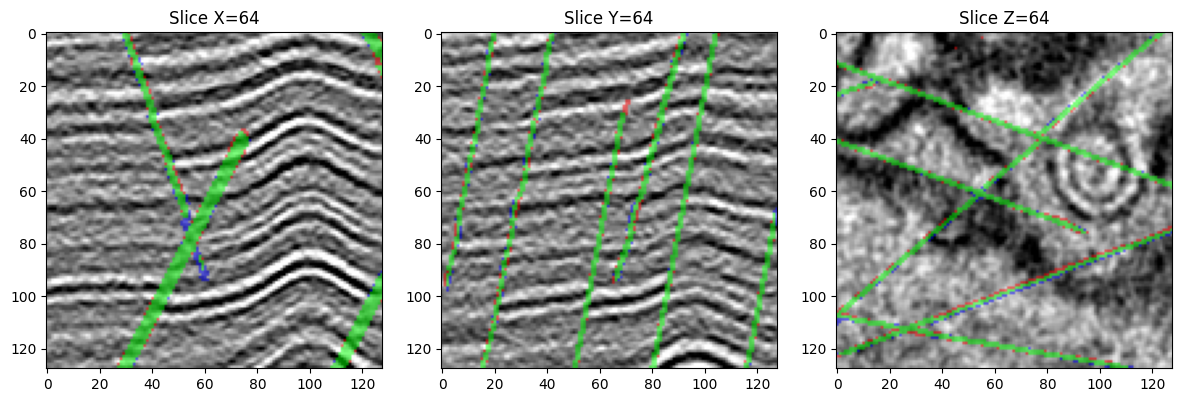

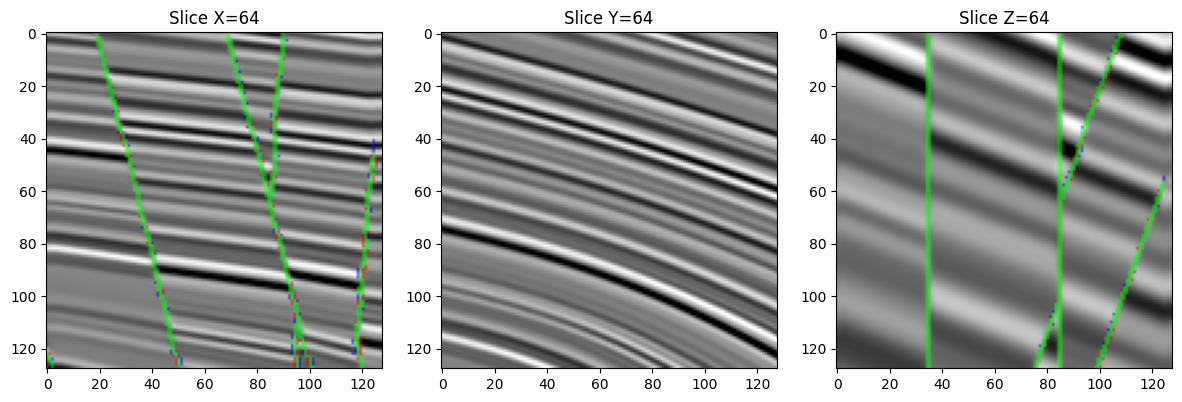

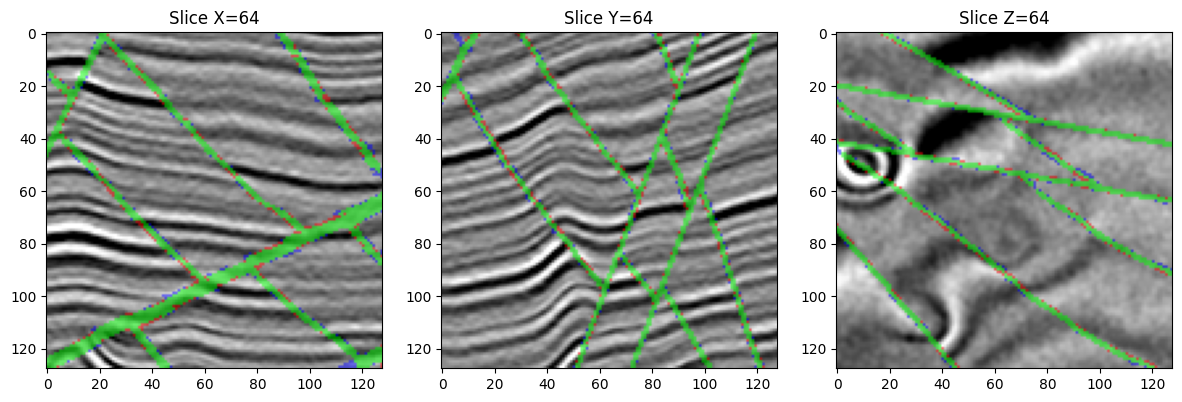

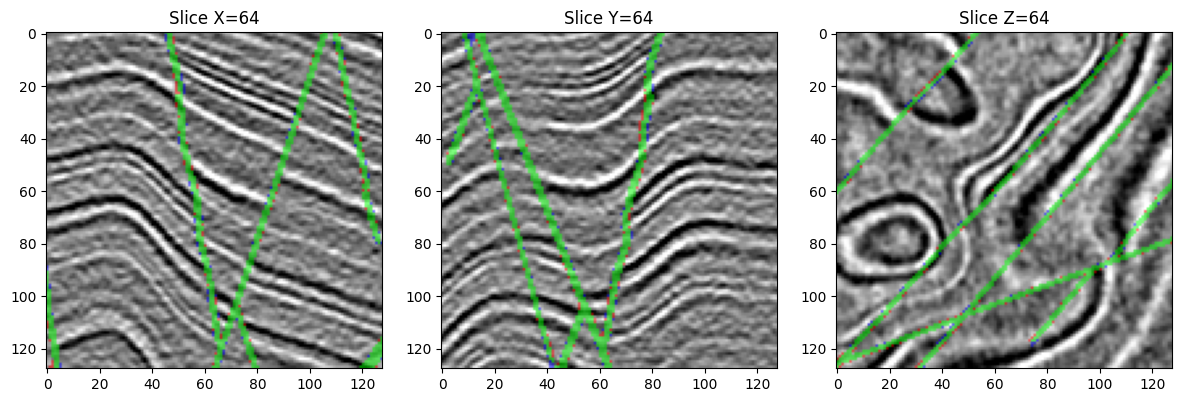

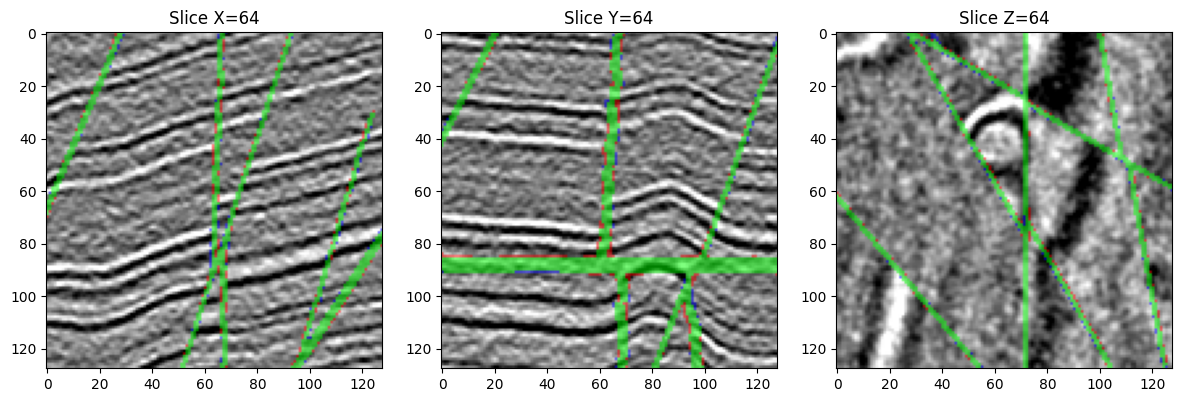

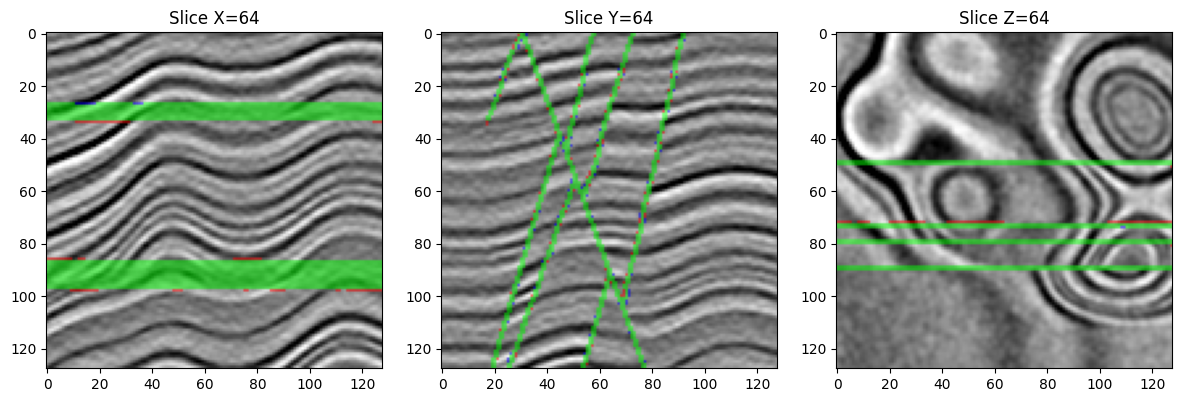

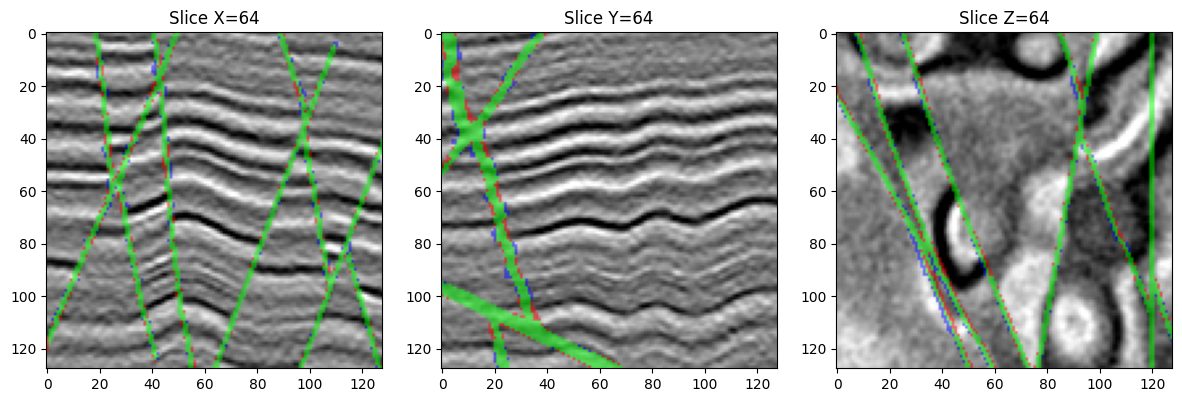

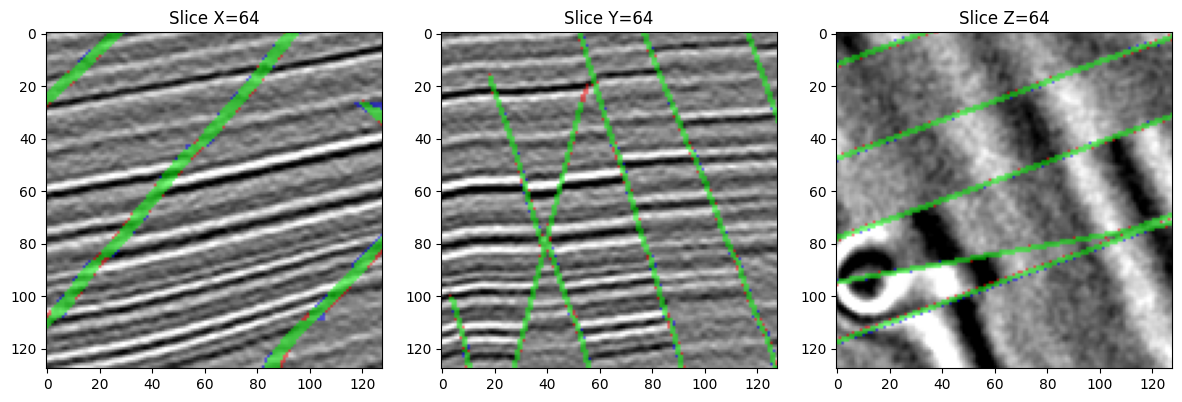

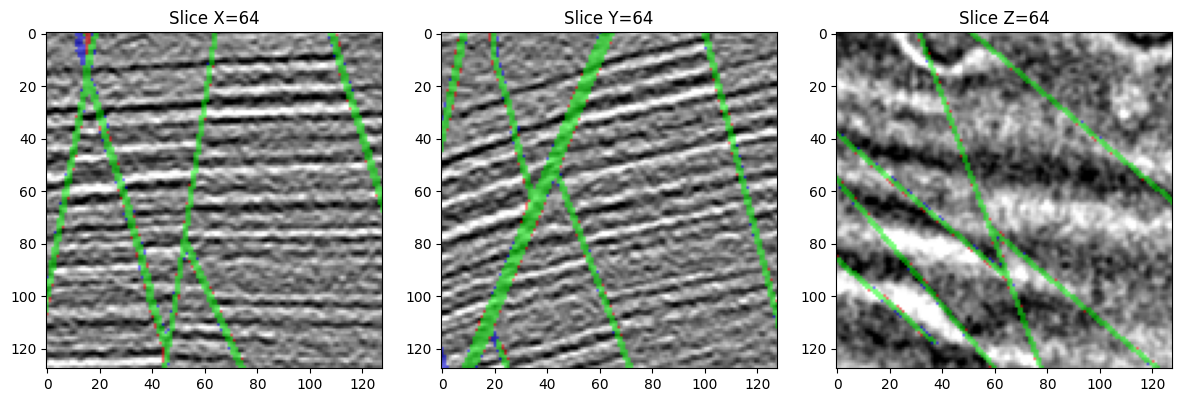

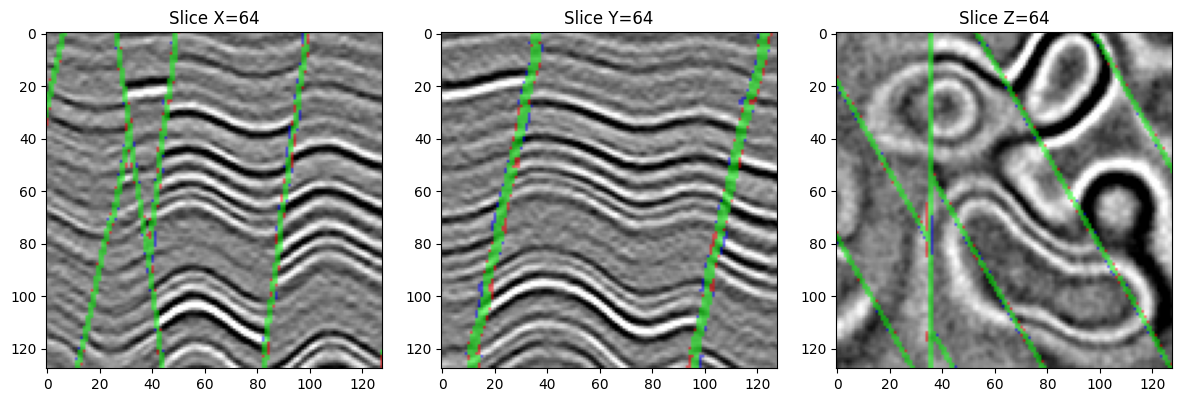

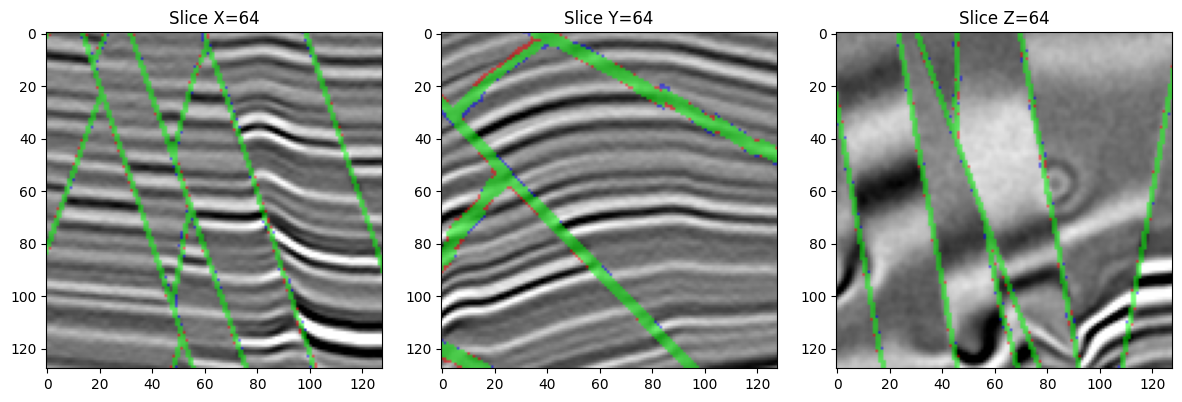

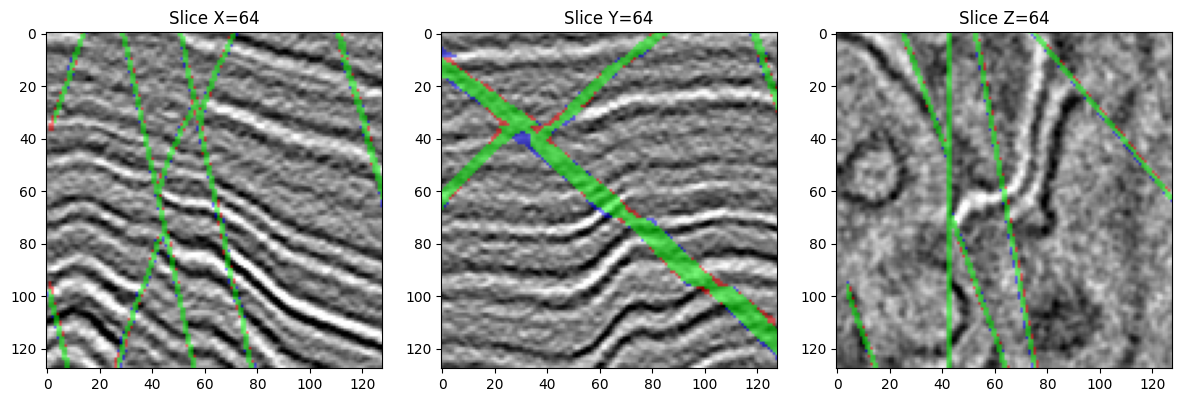

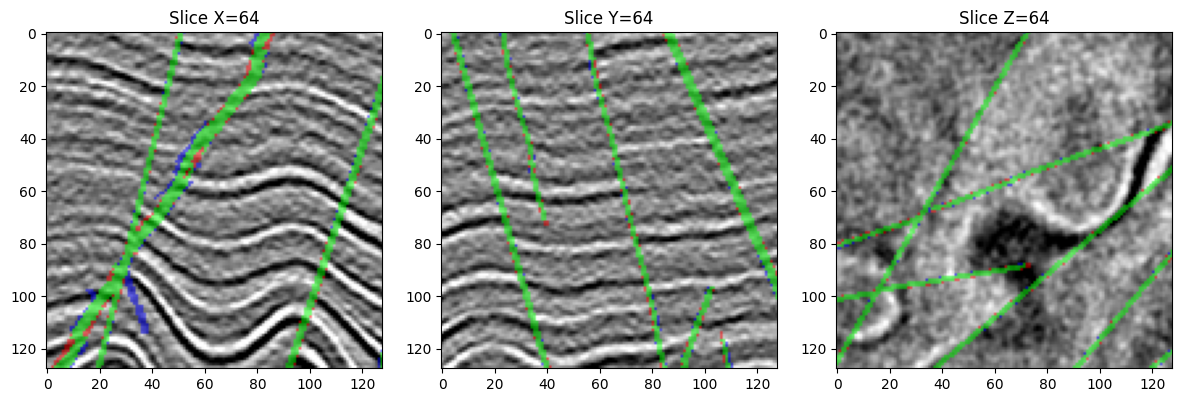

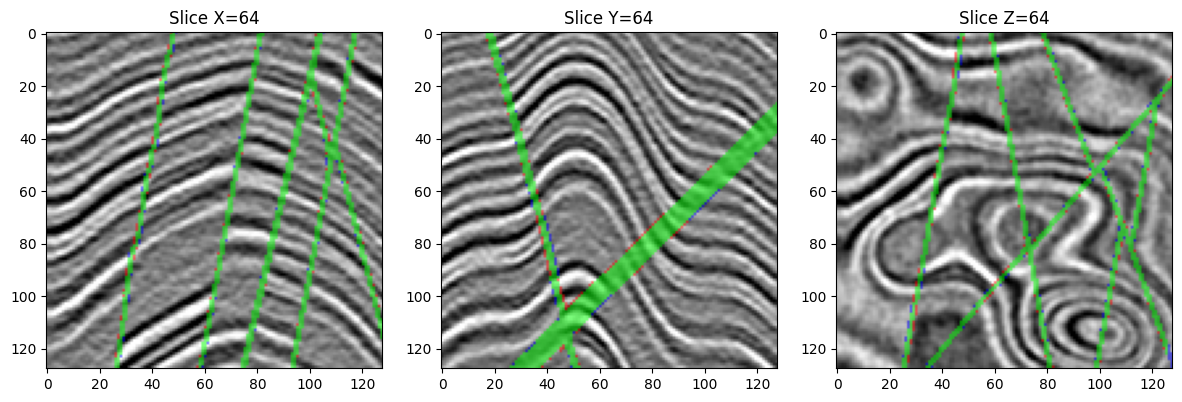

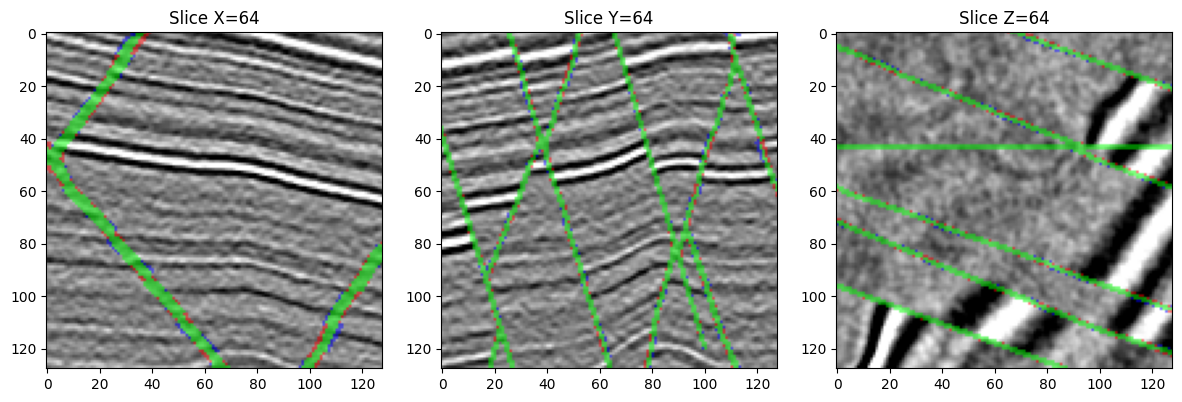

In [21]:
def plotPrediction(index, dataset=predictDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits    = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    inters  = (is_gt & is_pred)   # Acertos / Interseção

    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)
        

for i in range(min(len(predictDataset), 15)):
    plotPrediction(index=i)